In [4]:
'''
Complete Tactile Feedback code
'''
'''
Start of Train-Test results
'''

# --- Import Modules --- #
import sys, statistics, time, string, random
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np
import pandas as pd
import pickle 
import joblib
from sklearn.model_selection import train_test_split, StratifiedKFold

from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, fbeta_score, matthews_corrcoef
from sklearn.utils.multiclass import unique_labels

sys.path.insert(0, 'C:/Users/dema2/OneDrive/Desktop/PhD/Tactile-Feedback-Repo/Reflex-Fuzzy-Network')
from RFMN import ReflexFuzzyNeuroNetwork

np.set_printoptions(threshold=5)


In [5]:
'''
Data split for Iris.csv
'''
data = pd.read_csv('C:\\Users\\dema2\\OneDrive\\Desktop\\PhD\\Tactile-Feedback-Repo\\SaveModel\\Iris_feedback.csv')

data = data.iloc[:,1:]
# column names to use
# names = ['sepal-length', 'sepal-width', 'petal-length', 'petal-width', 'Label']

# read the dataset from the URL
# dataset = pd.read_csv(data, names=names)
# dataset = pd.read_csv(data)  
data.head()




# data = pd.read_csv('C:\\Users\\dema2\\OneDrive\\Desktop\\PhD\\Tactile-Feedback-Repo\\Reflex-Fuzzy-Network\\Arduino_train_test_D_F_W.csv')

# data = data.iloc[:,1:]

# print(data, "\n\n\n")

# X = data.iloc[:,:-1] # for every y (class) we get a 4-D array. E.g., I'm in the 5th dimension. 
# y = data.iloc[:,-1] # same as saying y coresponds to the respective classes. E.g., w = 1,2 or 3.

# print(X, "\n\n\n")
# print(y, "\n\n\n")


,sepal-length,sepal-width,petal-length,petal-width,Label
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,1
2,4.7,3.2,1.3,0.2,1
3,4.6,3.1,1.5,0.2,1
4,5.0,3.6,1.4,0.2,1


In [6]:
# separate the independent and dependent features
X = data.iloc[:, :-1].values
y = data.iloc[:, 4].values
print(type(X))

print(X)
print(y)

sepal_length = data.iloc[:, :-4].values
sepal_width = data.iloc[:, 1:-3].values
petal_length = data.iloc[:, 2:-2].values
petal_width = data.iloc[:, 3:-1].values

print(sepal_length)
print(sepal_width)
print(petal_length)
print(petal_width)



# X = data.iloc[:,:-1]
# y = data.iloc[:,-1]

<class 'numpy.ndarray'>
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 ...
 [6.5 3.  5.2 2. ]
 [6.2 3.4 5.4 2.3]
 [5.9 3.  5.1 1.8]]
[1 1 1 ... 3 3 3]
[[5.1]
 [4.9]
 [4.7]
 ...
 [6.5]
 [6.2]
 [5.9]]
[[3.5]
 [3. ]
 [3.2]
 ...
 [3. ]
 [3.4]
 [3. ]]
[[1.4]
 [1.4]
 [1.3]
 ...
 [5.2]
 [5.4]
 [5.1]]
[[0.2]
 [0.2]
 [0.2]
 ...
 [2. ]
 [2.3]
 [1.8]]


In [7]:
def get_array(X):
    data_point_array = []
    for element in np.nditer(X):
        # print(element)
        data_point = element

        data_point_array.append(data_point)

    return data_point_array

sepal_length_data = np.array(get_array(sepal_length))
sepal_width_data = np.array(get_array(sepal_width))
petal_length_data = np.array(get_array(petal_length))
petal_width_data = np.array(get_array(petal_width))

print(sepal_length_data)
print(sepal_width_data)
print(petal_length_data)
print(petal_width_data)

# Find the minimum and maximum
min_value_sepal_length = np.min(sepal_length_data)
max_value_sepal_length = np.max(sepal_length_data)
print(f"The minimum value is: {min_value_sepal_length}")
print(f"The maximum value is: {max_value_sepal_length} \n")

min_value_sepal_width = np.min(sepal_width_data)
max_value_sepal_width = np.max(sepal_width_data)
print(f"The minimum value is: {min_value_sepal_width}")
print(f"The maximum value is: {max_value_sepal_width} \n")

min_value_petal_length = np.min(petal_length_data)
max_value_petal_length = np.max(petal_length_data)
print(f"The minimum value is: {min_value_petal_length}")
print(f"The maximum value is: {max_value_petal_length} \n")

min_value_petal_width = np.min(petal_width_data)
max_value_petal_width = np.max(petal_width_data)
print(f"The minimum value is: {min_value_petal_width}")
print(f"The maximum value is: {max_value_petal_width} \n")
    

[5.1 4.9 4.7 ... 6.5 6.2 5.9]
[3.5 3.  3.2 ... 3.  3.4 3. ]
[1.4 1.4 1.3 ... 5.2 5.4 5.1]
[0.2 0.2 0.2 ... 2.  2.3 1.8]
The minimum value is: 4.3
The maximum value is: 7.9 

The minimum value is: 2.0
The maximum value is: 4.4 

The minimum value is: 1.0
The maximum value is: 6.9 

The minimum value is: 0.1
The maximum value is: 2.5 



In [8]:
print(sepal_length_data)
print(sepal_width_data)
print(petal_length_data)
print(petal_width_data)

# Calculate the size of each part
part_size_sepal_length_data = len(sepal_length_data) // 3
# Divide the array into three parts
part1_sepal_length_data = sepal_length_data[:part_size_sepal_length_data]

min_value_sepal_length = np.min(part1_sepal_length_data)
max_value_sepal_length = np.max(part1_sepal_length_data)
print(f"The minimum value is: {min_value_sepal_length}")
print(f"The maximum value is: {max_value_sepal_length} \n")

part2_sepal_length_data = sepal_length_data[part_size_sepal_length_data:2*part_size_sepal_length_data]

min_value_sepal_length = np.min(part2_sepal_length_data)
max_value_sepal_length = np.max(part2_sepal_length_data)
print(f"The minimum value is: {min_value_sepal_length}")
print(f"The maximum value is: {max_value_sepal_length} \n")

part3_sepal_length_data = sepal_length_data[2*part_size_sepal_length_data:]
min_value_sepal_length = np.min(part3_sepal_length_data)
max_value_sepal_length = np.max(part3_sepal_length_data)
print(f"The minimum value is: {min_value_sepal_length}")
print(f"The maximum value is: {max_value_sepal_length} \n")



# Calculate the size of each part
part_size_sepal_width_data = len(sepal_length_data) // 3
# Divide the array into three parts

part1_sepal_width_data = sepal_width_data[:part_size_sepal_width_data]
min_value_sepal_width = np.min(part1_sepal_width_data)
max_value_sepal_width = np.max(part1_sepal_width_data)
print(f"The minimum value is: {min_value_sepal_width}")
print(f"The maximum value is: {max_value_sepal_width} \n")

part2_sepal_width_data = sepal_width_data[part_size_sepal_width_data:2*part_size_sepal_width_data]
min_value_sepal_width = np.min(part2_sepal_width_data)
max_value_sepal_width = np.max(part2_sepal_width_data)
print(f"The minimum value is: {min_value_sepal_width}")
print(f"The maximum value is: {max_value_sepal_width} \n")

part3_sepal_width_data = sepal_width_data[2*part_size_sepal_width_data:]
min_value_sepal_width = np.min(part3_sepal_width_data)
max_value_sepal_width = np.max(part3_sepal_width_data)
print(f"The minimum value is: {min_value_sepal_width}")
print(f"The maximum value is: {max_value_sepal_width} \n")



# Calculate the size of each part
part_size_petal_length_data = len(petal_length_data) // 3
# Divide the array into three parts
part1_petal_length_data = petal_length_data[:part_size_petal_length_data]
min_value_petal_length = np.min(part1_petal_length_data)
max_value_petal_length = np.max(part1_petal_length_data)
print(f"The minimum value is: {min_value_petal_length}")
print(f"The maximum value is: {max_value_petal_length} \n")

part2_petal_length_data = petal_length_data[part_size_petal_length_data:2*part_size_petal_length_data]
min_value_petal_length = np.min(part2_petal_length_data)
max_value_petal_length = np.max(part2_petal_length_data)
print(f"The minimum value is: {min_value_petal_length}")
print(f"The maximum value is: {max_value_petal_length} \n")

part3_petal_length_data = petal_length_data[2*part_size_petal_length_data:]
min_value_petal_length = np.min(part3_petal_length_data)
max_value_petal_length = np.max(part3_petal_length_data)
print(f"The minimum value is: {min_value_petal_length}")
print(f"The maximum value is: {max_value_petal_length} \n")




# Calculate the size of each part
part_size_petal_width_data = len(petal_width_data) // 3
# Divide the array into three parts
part1_petal_width_data = petal_width_data[:part_size_petal_width_data]
min_value_petal_width = np.min(part1_petal_width_data)
max_value_petal_width = np.max(part1_petal_width_data)
print(f"The minimum value is: {min_value_petal_width}")
print(f"The maximum value is: {max_value_petal_width} \n")

part2_petal_width_data = petal_width_data[part_size_petal_width_data:2*part_size_petal_width_data]
min_value_petal_width = np.min(part2_petal_width_data)
max_value_petal_width = np.max(part2_petal_width_data)
print(f"The minimum value is: {min_value_petal_width}")
print(f"The maximum value is: {max_value_petal_width} \n")

part3_petal_width_data = petal_width_data[2*part_size_petal_width_data:]
min_value_petal_width = np.min(part3_petal_width_data)
max_value_petal_width = np.max(part3_petal_width_data)
print(f"The minimum value is: {min_value_petal_width}")
print(f"The maximum value is: {max_value_petal_width} \n")

[5.1 4.9 4.7 ... 6.5 6.2 5.9]
[3.5 3.  3.2 ... 3.  3.4 3. ]
[1.4 1.4 1.3 ... 5.2 5.4 5.1]
[0.2 0.2 0.2 ... 2.  2.3 1.8]
The minimum value is: 4.3
The maximum value is: 5.8 

The minimum value is: 4.9
The maximum value is: 7.0 

The minimum value is: 4.9
The maximum value is: 7.9 

The minimum value is: 2.3
The maximum value is: 4.4 

The minimum value is: 2.0
The maximum value is: 3.4 

The minimum value is: 2.2
The maximum value is: 3.8 

The minimum value is: 1.0
The maximum value is: 1.9 

The minimum value is: 3.0
The maximum value is: 5.1 

The minimum value is: 4.5
The maximum value is: 6.9 

The minimum value is: 0.1
The maximum value is: 0.6 

The minimum value is: 1.0
The maximum value is: 1.8 

The minimum value is: 1.4
The maximum value is: 2.5 



In [9]:
# '''
# Using the pickle library/ pickle file to save the ML model
# '''
# import pickle 

# # save the iris classification model as a pickle file
# model_pk1_file = "iris_classifier_model.pkl"

# with open(model_pk1_file, 'wb') as file:
#     pickle.dump(model, file)


In [10]:
buffer_size = 149 # You can adjust the buffer_size to control the number of data points used for the median calculation. 
                # A larger buffer size will provide better noise filtering but may introduce more delay.
data_buffer = []

def median_filter(data):
    data_buffer.append(data)
    if len(data_buffer) > buffer_size:
        data_buffer.pop(0)  # Remove the oldest data point

    # Calculate the median of the data in the buffer
    median_value = np.median(data_buffer)
    return median_value

# Simulate real-time data input (replace with your microprocessor data source)
def simulate_data_input(X):
    original_data = []
    filtered_data = []


    for element in np.nditer(X):
        # print(element)
        data_point = element  # Simulated data
        filtered_point = median_filter(data_point)


        original_data.append(data_point)
        filtered_data.append(filtered_point)


        # print(f"Original Data: {data_point}, Filtered Data: {filtered_point}")
        # print(f"Original Data: {data_point}, Filtered Data1: {filtered_point1}")



    return original_data, filtered_data

In [11]:
original_data, sepal_length_data = simulate_data_input(sepal_length)

# print(original_data)
# print(sepal_length_data)

original_data, sepal_width_data = simulate_data_input(sepal_width)

# print(original_data)
# print(sepal_width_data)


original_data, petal_length_data = simulate_data_input(petal_length)

# print(original_data)
# print(petal_length_data)

original_data, petal_width_data = simulate_data_input(petal_width)

# print(original_data)
# print(petal_width_data)

sepal_length_data = np.array(sepal_length_data)
sepal_width_data = np.array(sepal_width_data)
petal_length_data = np.array(petal_length_data)
petal_width_data = np.array(petal_width_data)



# print(len(sepal_length_data))
print(sepal_length_data)
print(sepal_width_data)
print(petal_length_data)
print(petal_width_data)

combined_array_X = np.vstack((sepal_length_data, sepal_width_data, petal_length_data, petal_width_data)).T

print(combined_array_X)


# # Find the minimum and maximum
# min_value_sepal_length = np.min(sepal_length_data)
# max_value_sepal_length = np.max(sepal_length_data)
# print(f"The minimum value is: {min_value_sepal_length}")
# print(f"The maximum value is: {max_value_sepal_length} \n")

# min_value_sepal_width = np.min(sepal_width_data)
# max_value_sepal_width = np.max(sepal_width_data)
# print(f"The minimum value is: {min_value_sepal_width}")
# print(f"The maximum value is: {max_value_sepal_width} \n")

# min_value_petal_length = np.min(petal_length_data)
# max_value_petal_length = np.max(petal_length_data)
# print(f"The minimum value is: {min_value_petal_length}")
# print(f"The maximum value is: {max_value_petal_length} \n")

# min_value_petal_width = np.min(petal_width_data)
# max_value_petal_width = np.max(petal_width_data)
# print(f"The minimum value is: {min_value_petal_width}")
# print(f"The maximum value is: {max_value_petal_width} \n")


[5.1 5.  4.9 ... 5.8 5.8 5.8]
[5.8 5.8 5.8 ... 3.  3.  3. ]
[3.  3.  3.  ... 4.3 4.3 4.4]
[4.4 4.4 4.4 ... 1.3 1.3 1.3]
[[5.1 5.8 3.  4.4]
 [5.  5.8 3.  4.4]
 [4.9 5.8 3.  4.4]
 ...
 [5.8 3.  4.3 1.3]
 [5.8 3.  4.3 1.3]
 [5.8 3.  4.4 1.3]]


In [12]:
print(sepal_length_data)
print(sepal_width_data)
print(petal_length_data)
print(petal_width_data)

# Calculate the size of each part
part_size_sepal_length_data = len(sepal_length_data) // 3
# Divide the array into three parts
part1_sepal_length_data = sepal_length_data[:part_size_sepal_length_data]

min_value_sepal_length = np.min(part1_sepal_length_data)
max_value_sepal_length = np.max(part1_sepal_length_data)
print(f"The minimum value is: {min_value_sepal_length}")
print(f"The maximum value is: {max_value_sepal_length} \n")

part2_sepal_length_data = sepal_length_data[part_size_sepal_length_data:2*part_size_sepal_length_data]

min_value_sepal_length = np.min(part2_sepal_length_data)
max_value_sepal_length = np.max(part2_sepal_length_data)
print(f"The minimum value is: {min_value_sepal_length}")
print(f"The maximum value is: {max_value_sepal_length} \n")

part3_sepal_length_data = sepal_length_data[2*part_size_sepal_length_data:]
min_value_sepal_length = np.min(part3_sepal_length_data)
max_value_sepal_length = np.max(part3_sepal_length_data)
print(f"The minimum value is: {min_value_sepal_length}")
print(f"The maximum value is: {max_value_sepal_length} \n")



# Calculate the size of each part
part_size_sepal_width_data = len(sepal_length_data) // 3
# Divide the array into three parts

part1_sepal_width_data = sepal_width_data[:part_size_sepal_width_data]
min_value_sepal_width = np.min(part1_sepal_width_data)
max_value_sepal_width = np.max(part1_sepal_width_data)
print(f"The minimum value is: {min_value_sepal_width}")
print(f"The maximum value is: {max_value_sepal_width} \n")

part2_sepal_width_data = sepal_width_data[part_size_sepal_width_data:2*part_size_sepal_width_data]
min_value_sepal_width = np.min(part2_sepal_width_data)
max_value_sepal_width = np.max(part2_sepal_width_data)
print(f"The minimum value is: {min_value_sepal_width}")
print(f"The maximum value is: {max_value_sepal_width} \n")

part3_sepal_width_data = sepal_width_data[2*part_size_sepal_width_data:]
min_value_sepal_width = np.min(part3_sepal_width_data)
max_value_sepal_width = np.max(part3_sepal_width_data)
print(f"The minimum value is: {min_value_sepal_width}")
print(f"The maximum value is: {max_value_sepal_width} \n")



# Calculate the size of each part
part_size_petal_length_data = len(petal_length_data) // 3
# Divide the array into three parts
part1_petal_length_data = petal_length_data[:part_size_petal_length_data]
min_value_petal_length = np.min(part1_petal_length_data)
max_value_petal_length = np.max(part1_petal_length_data)
print(f"The minimum value is: {min_value_petal_length}")
print(f"The maximum value is: {max_value_petal_length} \n")

part2_petal_length_data = petal_length_data[part_size_petal_length_data:2*part_size_petal_length_data]
min_value_petal_length = np.min(part2_petal_length_data)
max_value_petal_length = np.max(part2_petal_length_data)
print(f"The minimum value is: {min_value_petal_length}")
print(f"The maximum value is: {max_value_petal_length} \n")

part3_petal_length_data = petal_length_data[2*part_size_petal_length_data:]
min_value_petal_length = np.min(part3_petal_length_data)
max_value_petal_length = np.max(part3_petal_length_data)
print(f"The minimum value is: {min_value_petal_length}")
print(f"The maximum value is: {max_value_petal_length} \n")




# Calculate the size of each part
part_size_petal_width_data = len(petal_width_data) // 3
# Divide the array into three parts
part1_petal_width_data = petal_width_data[:part_size_petal_width_data]
min_value_petal_width = np.min(part1_petal_width_data)
max_value_petal_width = np.max(part1_petal_width_data)
print(f"The minimum value is: {min_value_petal_width}")
print(f"The maximum value is: {max_value_petal_width} \n")

part2_petal_width_data = petal_width_data[part_size_petal_width_data:2*part_size_petal_width_data]
min_value_petal_width = np.min(part2_petal_width_data)
max_value_petal_width = np.max(part2_petal_width_data)
print(f"The minimum value is: {min_value_petal_width}")
print(f"The maximum value is: {max_value_petal_width} \n")

part3_petal_width_data = petal_width_data[2*part_size_petal_width_data:]
min_value_petal_width = np.min(part3_petal_width_data)
max_value_petal_width = np.max(part3_petal_width_data)
print(f"The minimum value is: {min_value_petal_width}")
print(f"The maximum value is: {max_value_petal_width} \n")

[5.1 5.  4.9 ... 5.8 5.8 5.8]
[5.8 5.8 5.8 ... 3.  3.  3. ]
[3.  3.  3.  ... 4.3 4.3 4.4]
[4.4 4.4 4.4 ... 1.3 1.3 1.3]
The minimum value is: 4.800000000000001
The maximum value is: 5.1 

The minimum value is: 5.0
The maximum value is: 5.4 

The minimum value is: 5.4
The maximum value is: 5.8 

The minimum value is: 5.8
The maximum value is: 5.8 

The minimum value is: 3.4
The maximum value is: 5.7 

The minimum value is: 3.0
The maximum value is: 3.4 

The minimum value is: 2.7
The maximum value is: 3.0 

The minimum value is: 2.7
The maximum value is: 3.0 

The minimum value is: 3.0
The maximum value is: 4.4 

The minimum value is: 4.3
The maximum value is: 4.4 

The minimum value is: 1.3
The maximum value is: 4.3 

The minimum value is: 1.3
The maximum value is: 1.3 



In [13]:
# scaler_min_max = MinMaxScaler(feature_range=(0.001, .99))
# X_norm = scaler_min_max.fit_transform(X)

''' 
Ran after filtration
'''
# scaler_min_max = MinMaxScaler(feature_range=(0.001, .99))
# X_norm = scaler_min_max.fit_transform(combined_array_X)

X_norm = (combined_array_X-combined_array_X.min())/(combined_array_X.max()-combined_array_X.min())
print("this is X_norm \n", X_norm)


this is X_norm 
 [[0.84444444 1.         0.37777778 0.68888889]
 [0.82222222 1.         0.37777778 0.68888889]
 [0.8        1.         0.37777778 0.68888889]
 ...
 [1.         0.37777778 0.66666667 0.        ]
 [1.         0.37777778 0.66666667 0.        ]
 [1.         0.37777778 0.68888889 0.        ]]


In [14]:
# Split the data between train and test. 
X_train, X_test, y_train, y_test = train_test_split( X_norm, y, test_size=0.33, random_state=42) # Split the data to 33% to test, and 66% to training
                                            #These value come in four 66X1 matrices for X_train and X_test
                                            # and one 66X1 matrix for y_train and y_test. 
                                            # random state = 42
print(" This is X_train \n", X_train, "\n" )
print(" This is X_test \n", X_test, "\n" )
print(" This is y_train \n", y_train, "\n" )
print(" This is y_test \n", y_test, "\n" )


print("X train shape \n", X_train.shape)
print("Y train shape\n", y_train.shape)

print("X test shape \n", X_test.shape)
print("Y test shape\n", y_test.shape)

 This is X_train 
 [[0.91111111 0.46666667 0.37777778 0.        ]
 [0.93333333 0.44444444 0.37777778 0.        ]
 [0.84444444 0.93333333 0.31111111 0.6       ]
 ...
 [0.8        1.         0.37777778 0.68888889]
 [0.91111111 0.48888889 0.35555556 0.02222222]
 [0.93333333 0.46666667 0.37777778 0.        ]] 

 This is X_test 
 [[0.84444444 0.8        0.33333333 0.37777778]
 [0.82222222 1.         0.35555556 0.68888889]
 [0.95555556 0.42222222 0.42222222 0.        ]
 ...
 [0.97777778 0.37777778 0.6        0.        ]
 [0.85555556 0.64444444 0.33333333 0.06666667]
 [0.93333333 0.44444444 0.37777778 0.        ]] 

 This is y_train 
 [2 3 2 ... 1 2 3] 

 This is y_test 
 [2 1 3 ... 3 2 3] 

X train shape 
 (100, 4)
Y train shape
 (100,)
X test shape 
 (50, 4)
Y test shape
 (50,)


In [15]:
# y_train, y_test = y_train.values, y_test.values # Transpose the y_train and y_test data. 
                                # Essentailly we go from a 66X1 matrices to a 1x66 matrices. 

                           
X_train, X_test = X_train.T, X_test.T # Transpose the X_train and X_test data. 
                                # Essentailly we go from four 66X1 matrices to four 1x66 matrices. 
# print(" This is X_train.T \n", X_train, "\n" )
# print(" This is X_test.T \n", X_test, "\n" )
# print(" This is y_train.values \n", y_train, "\n" )
# print(" This is y_test.values \n", y_test, "\n" )



print("X train \n", X_train)
print("Y train \n", y_train)
# print("X train len \n", len(X_train))
# print("Y train len \n", len(y_train))

print("X test 1 \n", X_test)
print("Y test 1 \n", y_test)
# # # print("X test len \n", len(X_test))
# print("Y test len \n", len(y_test))

print("X train shape \n", X_train.shape)
print("Y train shape\n", y_train.shape)
print("X test shape \n", X_test.shape)
print("Y test shape\n", y_test.shape)

X train 
 [[0.91111111 0.93333333 0.84444444 ... 0.8        0.91111111 0.93333333]
 [0.46666667 0.44444444 0.93333333 ... 1.         0.48888889 0.46666667]
 [0.37777778 0.37777778 0.31111111 ... 0.37777778 0.35555556 0.37777778]
 [0.         0.         0.6        ... 0.68888889 0.02222222 0.        ]]
Y train 
 [2 3 2 ... 1 2 3]
X test 1 
 [[0.84444444 0.82222222 0.95555556 ... 0.97777778 0.85555556 0.93333333]
 [0.8        1.         0.42222222 ... 0.37777778 0.64444444 0.44444444]
 [0.33333333 0.35555556 0.42222222 ... 0.6        0.33333333 0.37777778]
 [0.37777778 0.68888889 0.         ... 0.         0.06666667 0.        ]]
Y test 1 
 [2 1 3 ... 3 2 3]
X train shape 
 (4, 100)
Y train shape
 (100,)
X test shape 
 (4, 50)
Y test shape
 (50,)


In [16]:
# # # --- Declare network --- "
nn = ReflexFuzzyNeuroNetwork(gamma=1, theta=.1)

'''
X_trian after the X_train.T (transponse) is an "array [[column 1,column 2, column 3, column 4"]]
y_train after the y_train.values (transpose) is an array[column 5]
'''

# --- Train network --- #
nn.train(X_train, y_train)

print("Model is trained")


Model is trained


In [29]:
# --- Test Network --- #
y_predlr = nn.test(X_test,y_test)

print(type(y_predlr))
print("done with predictions")

[2 1 3 2 2 1 2 3 2 2 3 1 1 1 1 2 3 2 2 3 1 3 1 3 3 3 3 3 1 1 1 1 2 1 1 3 2
 1 1 1 3 2 2 1 1 2 3 3 2 3]
<class 'numpy.ndarray'>
done with predictions


In [18]:
# check results
print("confusion_matrix \n", confusion_matrix(y_test, y_predlr), "\n")
print("classification_report \n", classification_report(y_test, y_predlr), "\n")
     

confusion_matrix 
 [[19  0  0]
 [ 0 15  0]
 [ 0  0 16]] 

classification_report 
               precision    recall  f1-score   support

           1       1.00      1.00      1.00        19
           2       1.00      1.00      1.00        15
           3       1.00      1.00      1.00        16

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50
 



In [19]:
np.set_printoptions(threshold=sys.maxsize)
unique_labels(y_test)

def plot(y_true, y_pred):
    labels = unique_labels(y_test)
    column = [f'Predicted {label}' for label in labels]
    indices = [f'Actual {label}' for label in labels]
    table = pd.DataFrame(confusion_matrix(y_true, y_pred), columns = column, index=indices)

    return table


plot(y_test, y_predlr)

,Predicted 1,Predicted 2,Predicted 3
Actual 1,19,0,0
Actual 2,0,15,0
Actual 3,0,0,16


1.0


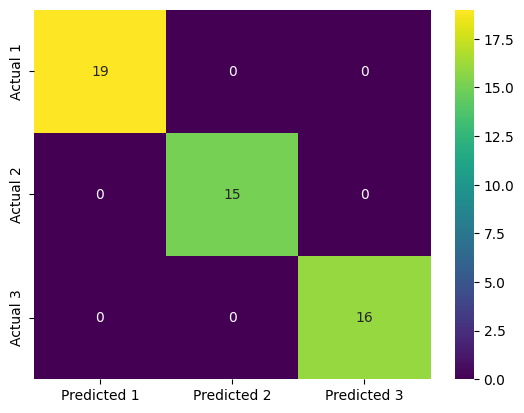

In [20]:
def plot2(y_true, y_pred):
    labels = unique_labels(y_test)
    column = [f'Predicted {label}' for label in labels]
    indices = [f'Actual {label}' for label in labels]
    table = pd.DataFrame(confusion_matrix(y_true, y_pred), columns = column, index=indices)

    return sns.heatmap(table, annot = True, fmt = 'd', cmap= 'viridis')

plot2(y_test, y_predlr)

accuracy_score1 = accuracy_score(y_test, y_predlr)
print(accuracy_score1)


In [21]:
'''
Start of Cross validation results
'''

# initialise a StratifiedKFold object with 5 folds and
# declare the column that we which to group by which in this
# case is the column called "label"
n_splits=10
skf = StratifiedKFold(n_splits=n_splits, shuffle= True, random_state=42)

target = data.loc[:,'Label']



In [22]:
# for each fold split the data into train and validation 
# sets and save the fold splits to csv
fold_no = 1
for train_index, val_index in skf.split(data, target):
    train = data.loc[train_index,:]
    val = data.loc[val_index,:]
    # train.to_csv('C:\\Users\\dema2\\OneDrive\\Desktop\\PhD\\Tactile-Feedback-Repo\\cross_val_data_D_F_W\\' + 'train_fold_' + str(fold_no) + '.csv')
    # val.to_csv('C:\\Users\\dema2\\OneDrive\\Desktop\\PhD\\Tactile-Feedback-Repo\\cross_val_data_D_F_W\\' + 'val_fold_' + str(fold_no) + '.csv')
    
    
    train.to_csv('C:\\Users\\dema2\\OneDrive\\Desktop\\PhD\\Tactile-Feedback-Repo\\cross_val_data_iris\\' + 'train_fold_' + str(fold_no) + '.csv')
    val.to_csv('C:\\Users\\dema2\\OneDrive\\Desktop\\PhD\\Tactile-Feedback-Repo\\cross_val_data_iris\\' + 'val_fold_' + str(fold_no) + '.csv')
    fold_no += 1

[1 1 1 1 1 3 3 2 2 2 3 3 3 3 3]
[1 1 1 1 1 2 2 2 3 2 3 3 3 3 3]
[1 1 1 1 1 2 2 2 2 2 3 3 3 3 3]
[1 1 1 1 1 2 2 2 2 2 2 3 3 3 3]
[1 1 1 2 1 2 2 2 3 2 3 3 3 3 2]
[1 1 1 1 1 2 2 3 2 2 3 3 3 3 3]
[1 1 1 1 1 2 2 2 2 2 3 3 3 3 3]
[1 1 1 1 1 2 2 2 3 2 3 3 3 3 3]
[1 1 1 1 1 2 2 3 3 2 2 3 3 3 3]
[1 1 1 1 1 2 3 2 2 3 3 2 3 3 3]


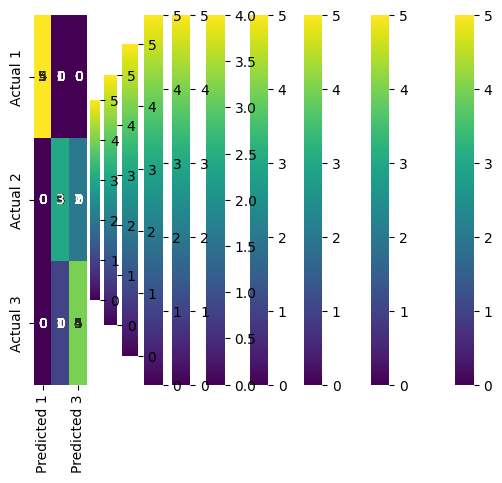

In [23]:
count = 1
accuracy_array = []
count_array = []
for fold_no in range(1,n_splits+1):

    newtrain = pd.read_csv('C:\\Users\\dema2\\OneDrive\\Desktop\\PhD\\Tactile-Feedback-Repo\\cross_val_data_iris\\' + 'train_fold_' + str(fold_no) + '.csv')
    newval = pd.read_csv('C:\\Users\\dema2\\OneDrive\\Desktop\\PhD\\Tactile-Feedback-Repo\\cross_val_data_iris\\' + 'val_fold_' + str(fold_no) + '.csv')

    newtrain = newtrain.iloc[:,1:]
    
    newval = newval.iloc[:,1:]


    X_train_val = newtrain.iloc[:,:-1]
    y_train_val = newtrain.iloc[:,-1]

    X_test_val = newval.iloc[:,:-1]
    y_test_val = newval.iloc[:,-1] 

    # # I need to pass this through a filter first in the future. 
    # X_train_val = (X_train_val-X_train_val.min())/(X_train_val.max()-X_train_val.min())
    # X_test_val = (X_test_val-X_test_val.min())/(X_test_val.max()-X_test_val.min())

    scaler_min_max = MinMaxScaler(feature_range=(0.01, .99))
    X_train_val = scaler_min_max.fit_transform(X_train_val)
    X_test_val = scaler_min_max.fit_transform(X_test_val)

    y_train_val, y_test_val = y_train_val.values, y_test_val.values 
    X_train_val, X_test_val = X_train_val.T, X_test_val.T 

    # # # --- Declare network --- "
    nn_val = ReflexFuzzyNeuroNetwork(gamma=2, theta=.001)

    # --- Train network --- #
    nn_val.train(X_train_val, y_train_val)
    y_predlr_val = nn_val.test(X_test_val,y_test_val)

    # check results
    # print("confusion_matrix for count \n", confusion_matrix(y_test_val, y_predlr_val), "\n")
    # print("classification_report for count \n", classification_report(y_test_val,y_predlr_val), "\n")

    np.set_printoptions(threshold=sys.maxsize)
    unique_labels(y_test_val)

    # def plot is the smae as plot2, except it looks better when analysing. 
    def plot(y_true, y_pred):
        labels = unique_labels(y_test_val)
        column = [f'Predicted {label}' for label in labels]
        indices = [f'Actual {label}' for label in labels]
        table = pd.DataFrame(confusion_matrix(y_true, y_pred), columns = column, index=indices)
        return table
    
    def plot2(y_true, y_pred):
        labels = unique_labels(y_test_val)
        column = [f'Predicted {label}' for label in labels]
        indices = [f'Actual {label}' for label in labels]
        table = pd.DataFrame(confusion_matrix(y_true, y_pred), columns = column, index=indices)
        return sns.heatmap(table, annot = True, fmt = 'd', cmap= 'viridis')
    
    # plot(y_test_val, y_predlr_val)
    plot2(y_test_val, y_predlr_val)

    accuracy_score1 = accuracy_score(y_test_val, y_predlr_val)
    accuracy_array.append(accuracy_score1)
    count_array.append(count)
    # print("Accuracy for count", accuracy_score1)
    # print("Done with count: ", count)

    # print("Accuracy array for count" + count + "\n", accuracy)
    # print("done with count array", count_array)

    count +=1


Accuracy out of loop:  [0.8666666666666667, 0.9333333333333333, 1.0, 0.9333333333333333, 0.8, 0.9333333333333333, 1.0, 0.9333333333333333, 0.8, 0.8]
Count out of loop:  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
std 0.0785674201318386
mean 0.9


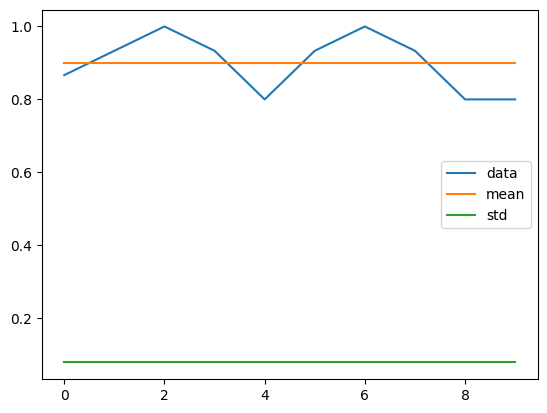

In [24]:
print("Accuracy out of loop: ", accuracy_array)
print("Count out of loop: ", count_array)
print("std", statistics.stdev(accuracy_array))
print("mean", statistics.mean(accuracy_array))

df = pd.DataFrame({
      'data': accuracy_array,
      'mean': [statistics.mean(accuracy_array) for i in range(1, len(accuracy_array)+1, 1)],
      'std': [statistics.stdev(accuracy_array) for i in range(1, len(accuracy_array)+1, 1)]})

df.plot()
plt.show()

[[1.3 5.7 3.  4.1]
 [1.3 5.7 3.  4.1]
 [1.4 5.7 3.  4.1]
 [1.4 5.7 3.  4.1]
 [1.4 5.7 3.  4.1]
 [1.4 5.7 3.  4.1]
 [1.4 5.7 3.  4.1]
 [1.4 5.7 3.  4.1]
 [1.4 5.7 3.  4.1]
 [1.4 5.7 3.  4.1]
 [1.5 5.7 3.  4.1]
 [1.5 5.7 3.  4.1]
 [1.5 5.7 3.  4.1]
 [1.5 5.7 3.  4.1]
 [1.5 5.7 3.  4.1]
 [1.5 5.7 3.  4.1]
 [1.5 5.7 3.  4.1]
 [1.5 5.7 3.  4.1]
 [1.5 5.7 3.  4.1]
 [1.5 5.7 3.  4.1]
 [1.5 5.7 3.  4.1]
 [1.5 5.7 3.  4.1]
 [1.6 5.7 3.  4.1]
 [1.6 5.7 2.9 4.1]
 [1.6 5.7 2.9 4.1]
 [1.6 5.7 2.9 4.1]
 [1.7 5.7 2.9 4.1]
 [1.7 5.6 2.9 4.1]
 [1.8 5.6 2.9 4.1]
 [1.8 5.6 2.9 4.1]
 [1.8 5.6 2.8 4.1]
 [1.8 5.6 2.8 4.1]
 [1.8 5.6 2.8 4.1]
 [1.8 5.6 2.8 4.1]
 [1.8 5.6 2.8 4.1]
 [1.8 5.6 2.8 4.1]
 [1.8 5.6 2.8 4.1]
 [1.8 5.6 2.8 4.1]
 [1.8 5.6 2.8 4.1]
 [1.8 5.6 2.8 4.1]
 [1.9 5.6 2.8 4.1]
 [1.9 5.6 2.8 4.1]
 [1.9 5.6 2.8 4.1]
 [1.9 5.6 2.7 4.1]
 [1.9 5.6 2.7 4.1]
 [2.  5.6 2.7 4.1]
 [2.  5.6 2.7 4.1]
 [2.  5.6 2.7 4.1]
 [2.  5.6 2.7 4.1]
 [2.  5.6 2.7 4.1]
 [2.  5.6 2.7 4.1]
 [2.1 5.6 2.7 4.1]
 [2.1 5.6 2.

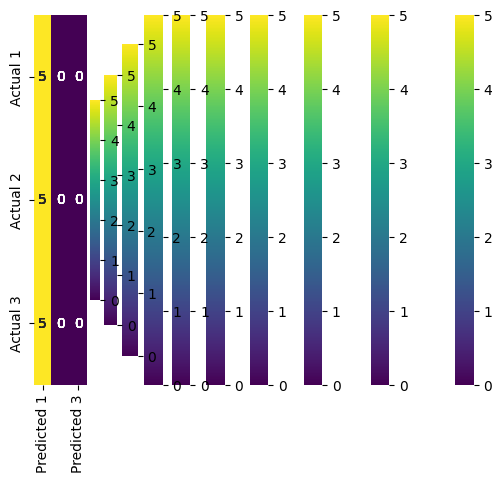

In [25]:
count = 1
accuracy_array = []
count_array = []
for fold_no in range(1,n_splits+1):

    newtrain = pd.read_csv('C:\\Users\\dema2\\OneDrive\\Desktop\\PhD\\Tactile-Feedback-Repo\\cross_val_data_iris\\' + 'train_fold_' + str(fold_no) + '.csv')
    newval = pd.read_csv('C:\\Users\\dema2\\OneDrive\\Desktop\\PhD\\Tactile-Feedback-Repo\\cross_val_data_iris\\' + 'val_fold_' + str(fold_no) + '.csv')

    newtrain = newtrain.iloc[:,1:]
    
    newval = newval.iloc[:,1:]


    # X_train_val = newtrain.iloc[:,:-1].values
    y_train_val = newtrain.iloc[:,-1].values

    sepal_length_train_val = newtrain.iloc[:, :-4].values
    sepal_width_train_val = newtrain.iloc[:, 1:-3].values
    petal_length_train_val = newtrain.iloc[:, 2:-2].values
    petal_width_train_val = newtrain.iloc[:, 3:-1].values

    original_data, sepal_length_data_train_val = simulate_data_input(sepal_length_train_val)
    original_data, sepal_width_data_train_val = simulate_data_input(sepal_width_train_val)
    original_data, petal_length_data_train_val = simulate_data_input(petal_length_train_val)
    original_data, petal_width_data_train_val = simulate_data_input(petal_width_train_val)
    sepal_length_data_train_val = np.array(sepal_length_data_train_val)
    sepal_width_data_train_val = np.array(sepal_width_data_train_val)
    petal_length_data_train_val = np.array(petal_length_data_train_val)
    petal_width_data_train_val = np.array(petal_width_data_train_val)
    combined_array_X_train_val = np.vstack((sepal_length_data_train_val, sepal_width_data_train_val, 
                                            petal_length_data_train_val, petal_width_data_train_val)).T
    print(combined_array_X_train_val)




    # X_test_val = newval.iloc[:,:-1].values
    y_test_val = newval.iloc[:,-1].values

    sepal_length_test_val = newval.iloc[:, :-4].values
    sepal_width_test_val = newval.iloc[:, 1:-3].values
    petal_length_test_val = newval.iloc[:, 2:-2].values
    petal_width_test_val = newval.iloc[:, 3:-1].values

    original_data, sepal_length_data_test_val = simulate_data_input(sepal_length_test_val)
    original_data, sepal_width_data_test_val = simulate_data_input(sepal_width_test_val)
    original_data, petal_length_data_test_val = simulate_data_input(petal_length_test_val)
    original_data, petal_width_data_test_val = simulate_data_input(petal_width_test_val)
    sepal_length_data_test_val = np.array(sepal_length_data_test_val)
    sepal_width_data_test_val = np.array(sepal_width_data_test_val)
    petal_length_data_test_val = np.array(petal_length_data_test_val)
    petal_width_data_test_val = np.array(petal_width_data_test_val)
    combined_array_X_test_val = np.vstack((sepal_length_data_test_val, sepal_width_data_test_val, 
                                            petal_length_data_test_val, petal_width_data_test_val)).T
    print(combined_array_X_test_val)

    

    scaler_min_max = MinMaxScaler(feature_range=(0.01, .99))

    
    combined_array_X_train_val = scaler_min_max.fit_transform(combined_array_X_train_val)
    combined_array_X_test_val = scaler_min_max.fit_transform(combined_array_X_test_val)

    # y_train_val, y_test_val = y_train_val.values, y_test_val.values 
    combined_array_X_train_val, combined_array_X_test_val = combined_array_X_train_val.T, combined_array_X_test_val.T 

    # # # --- Declare network --- "
    nn_val = ReflexFuzzyNeuroNetwork(gamma=2, theta=.001)

    # --- Train network --- #
    nn_val.train(combined_array_X_train_val, y_train_val)
    y_predlr_val = nn_val.test(combined_array_X_test_val,y_test_val)

    # check results
    # print("confusion_matrix for count \n", confusion_matrix(y_test_val, y_predlr_val), "\n")
    # print("classification_report for count \n", classification_report(y_test_val,y_predlr_val), "\n")

    np.set_printoptions(threshold=sys.maxsize)
    unique_labels(y_test_val)

    # def plot is the smae as plot2, except it looks better when analysing. 
    def plot(y_true, y_pred):
        labels = unique_labels(y_test_val)
        column = [f'Predicted {label}' for label in labels]
        indices = [f'Actual {label}' for label in labels]
        table = pd.DataFrame(confusion_matrix(y_true, y_pred), columns = column, index=indices)
        return table
    
    def plot2(y_true, y_pred):
        labels = unique_labels(y_test_val)
        column = [f'Predicted {label}' for label in labels]
        indices = [f'Actual {label}' for label in labels]
        table = pd.DataFrame(confusion_matrix(y_true, y_pred), columns = column, index=indices)
        return sns.heatmap(table, annot = True, fmt = 'd', cmap= 'viridis')
    
    # plot(y_test_val, y_predlr_val)
    plot2(y_test_val, y_predlr_val)

    accuracy_score1 = accuracy_score(y_test_val, y_predlr_val)
    accuracy_array.append(accuracy_score1)
    count_array.append(count)
    # print("Accuracy for count", accuracy_score1)
    # print("Done with count: ", count)

    # print("Accuracy array for count" + count + "\n", accuracy)
    # print("done with count array", count_array)

    count +=1

Accuracy out of loop:  [0.3333333333333333, 0.3333333333333333, 0.3333333333333333, 0.3333333333333333, 0.3333333333333333, 0.3333333333333333, 0.3333333333333333, 0.3333333333333333, 0.3333333333333333, 0.3333333333333333]
Count out of loop:  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
std 0.0
mean 0.3333333333333333


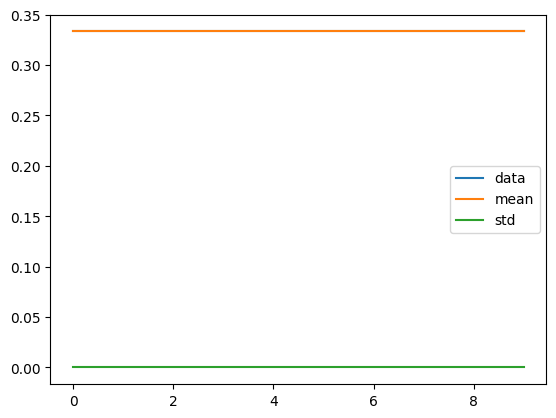

In [26]:
print("Accuracy out of loop: ", accuracy_array)
print("Count out of loop: ", count_array)
print("std", statistics.stdev(accuracy_array))
print("mean", statistics.mean(accuracy_array))

df = pd.DataFrame({
      'data': accuracy_array,
      'mean': [statistics.mean(accuracy_array) for i in range(1, len(accuracy_array)+1, 1)],
      'std': [statistics.stdev(accuracy_array) for i in range(1, len(accuracy_array)+1, 1)]})

df.plot()
plt.show()

In [27]:
'''
Using the pickle library/ pickle file to save the ML model
'''
import pickle 

# save the iris classification model as a pickle file
model_pk1_file = "iris_RFMN_model.pkl"

with open(model_pk1_file, 'wb') as file:
    pickle.dump(nn, file)

    

In [28]:
# load model from pickle file
with open(model_pk1_file, "rb") as file: 
    model = pickle.load(file)

# --- Test Network --- #
y_predict = nn.test(X_test,y_test)

print("done with predictions")

# check results
print(classification_report(y_test, y_predict))

[2 1 3 2 2 1 2 3 2 2 3 1 1 1 1 2 3 2 2 3 1 3 1 3 3 3 3 3 1 1 1 1 2 1 1 3 2
 1 1 1 3 2 2 1 1 2 3 3 2 3]
done with predictions
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        19
           2       1.00      1.00      1.00        15
           3       1.00      1.00      1.00        16

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50

